## WGAN hopefully

In [1]:
from pathlib import Path
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F

In [3]:
import sys, os
sys.path.append(os.path.abspath(".."))

In [4]:
from src.load_sam_data import load_dataset
from src.plotting_styles import apply_global_style
from src.autoencoders import minmax_scale_per_sample
from src.autoencoders import drop_empty_histograms

data_dir = "FJ"
dataset = load_dataset(data_dir)
full_dataset = np.array(dataset)
full_dataset = minmax_scale_per_sample(full_dataset)

dataset_no_outs = drop_empty_histograms(full_dataset)

..\data\FJ\FI01X1\FI01X1_ch
Dropped indexes [8, 15, 188, 214, 263, 268, 533, 546]


<BarContainer object of 96 artists>

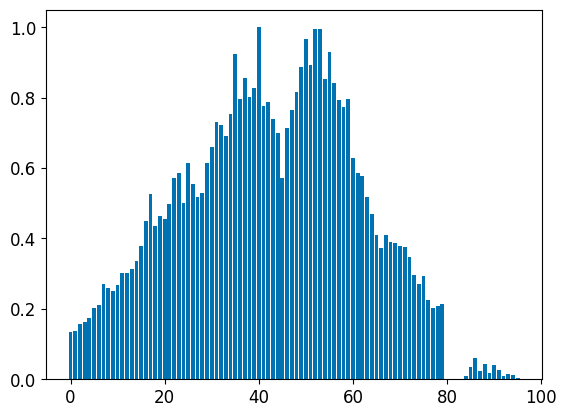

In [45]:
plt.bar(range(96), full_dataset[499])

In [5]:
from sklearn.model_selection import train_test_split

X_train, X_test = train_test_split(dataset_no_outs, shuffle=True, train_size=0.8, random_state=42)

In [6]:
dataset_no_outs = torch.from_numpy(dataset_no_outs)
X_train = torch.from_numpy(X_train)
X_test = torch.from_numpy(X_test)
full_dataset = torch.from_numpy(full_dataset)

dataset_no_outs = dataset_no_outs.to(torch.float32)
X_train = X_train.to(torch.float32)
X_test = X_test.to(torch.float32)
full_dataset = full_dataset.to(torch.float32)

In [114]:
pt = torch.zeros(20).reshape(1,1,20)
generator = nn.Sequential(
                nn.ConvTranspose1d(in_channels=1, out_channels=4, kernel_size=4, stride=1),
                nn.ReLU(),
                nn.ConvTranspose1d(in_channels=4, out_channels=16, kernel_size=4, stride=2),
                nn.ReLU(),
                nn.ConvTranspose1d(in_channels=16, out_channels=16, kernel_size=4, stride=3))
torch.flatten(generator(pt)).shape

torch.Size([2320])

In [127]:
# baseline on linear layers

class Generator(nn.Module):
    def __init__(self):
        super(Generator, self).__init__()

        self.conv1 = nn.ConvTranspose1d(in_channels=1, out_channels=4, kernel_size=4, stride=1)
        self.conv2 = nn.ConvTranspose1d(in_channels=4, out_channels=16, kernel_size=4, stride=2)
        self.conv3 = nn.ConvTranspose1d(in_channels=16, out_channels=16, kernel_size=4, stride=3)
        self.fc1 =  nn.Linear(2320, 1600)
        self.fc2 =  nn.Linear(1600, 512)
        self.fc3 = nn.Linear(512, 256)
        self.fc4 = nn.Linear(256, 128)
        self.fc5 = nn.Linear(128, 96)

    
    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = F.relu(self.conv3(x))
        x = torch.flatten(x, start_dim=1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = F.relu(self.fc3(x))
        x = F.relu(self.fc4(x))
        x = F.sigmoid(self.fc5(x))
        return x
    
class Critic(nn.Module):
    def __init__(self):
        super(Critic, self).__init__()
        #self.conv1 = nn.Conv1d(in_channels=1, out_channels=4, kernel_size=4, stride=2)
        #self.conv2 = nn.Conv1d(in_channels=4, out_channels=8, kernel_size=4, stride=2)
        #self.conv3 = nn.Conv1d(in_channels=8, out_channels=16, kernel_size=4, stride=2)
        #self.fc1 = nn.Linear(160, 64)
        #self.fc2 = nn.Linear(64, 1)

        self.fc1 = nn.Linear(96, 80)
        self.fc2 = nn.Linear(80, 60)
        self.fc3 = nn.Linear(60, 40)
        self.fc4 = nn.Linear(40, 1)

    def forward(self, x):
        # first layer torch.Size([16, 4, 47])
        # second layer torch.Size([16, 8, 22])
        # third layer torch.Size([16, 16, 10])
        
        x = F.leaky_relu(self.fc1(x), negative_slope=0.2)
        x = F.leaky_relu(self.fc2(x), negative_slope=0.2)
        x = F.leaky_relu(self.fc3(x), negative_slope=0.2)
        #x = torch.flatten(x, start_dim=1)
        x = self.fc4(x)
        return x

In [47]:
from torch.utils.data import Dataset, DataLoader
from torch.utils.data import DataLoader

class HistDataset(Dataset):
    def __init__(self, data):
        self.data = data

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        hist = self.data[idx]
        hist = torch.tensor(hist, dtype=torch.float32)
        return hist

In [131]:
batch_size = 32

torch_df = HistDataset(full_dataset)
dataloader = DataLoader(torch_df, batch_size=batch_size, shuffle=True)
#train_dataset = HistDataset(X_train)
#test_dataset = HistDataset(X_test)

#train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
#test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

gen = Generator()
critic = Critic()

lr = 0.0001
num_epochs = 200
latent_dim = 20
clip = 0.01
critic_iterations = 10
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [132]:
optimizer_G = torch.optim.Adam(gen.parameters(), lr=lr)
optimizer_C = torch.optim.Adam(critic.parameters(), lr=lr)

In [133]:
losses_D = []
losses_G = []

point_dim = len(dataset[0])

for epoch in range(num_epochs):
    for i, real_data in enumerate(dataloader):

        batch_size = real_data.size(0)
        
        real_labels = torch.ones(batch_size, 1, 1, device=device) 
        fake_labels = torch.zeros(batch_size, 1, 1, device=device)
       
        for _ in range(critic_iterations):
            # generated data
            z = torch.randn(batch_size, 1, latent_dim, device=device)
            fake_data = gen(z) # output: 16 x 96
            critic_real = critic(real_data)
            critic_fake = critic(fake_data)
            loss_C = -(torch.mean(critic_real) - torch.mean(critic_fake))
            
            optimizer_C.zero_grad()
            loss_C.backward(retain_graph=True)
            optimizer_C.step()
        
        for p in critic.parameters():
                p.data.clamp_(-clip, clip)
        
        gen_fake = critic(fake_data).reshape(-1)
        loss_G = -torch.mean(gen_fake)
        optimizer_G.zero_grad()
        loss_G.backward()
        optimizer_G.step()
        
    losses_D.append(loss_C.item())
    losses_G.append(loss_G.item())

    if epoch % 20 == 0:
        print(f"Ep {epoch+1}/{num_epochs} Loss D: {loss_C.item():.4f}, Loss G: {loss_G.item():.4f}")

C:\Users\hrdyj\AppData\Local\Temp\ipykernel_42252\2451661108.py:13: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  hist = torch.tensor(hist, dtype=torch.float32)


Ep 1/200 Loss D: -0.0001, Loss G: 0.0097
Ep 21/200 Loss D: 0.0000, Loss G: 0.0133
Ep 41/200 Loss D: 0.0000, Loss G: 0.0158
Ep 61/200 Loss D: -0.0010, Loss G: 0.0144
Ep 81/200 Loss D: -0.0012, Loss G: 0.0137
Ep 101/200 Loss D: 0.0008, Loss G: 0.0137
Ep 121/200 Loss D: -0.0055, Loss G: 0.0143
Ep 141/200 Loss D: 0.0020, Loss G: 0.0144
Ep 161/200 Loss D: 0.0005, Loss G: 0.0134
Ep 181/200 Loss D: -0.0063, Loss G: 0.0171


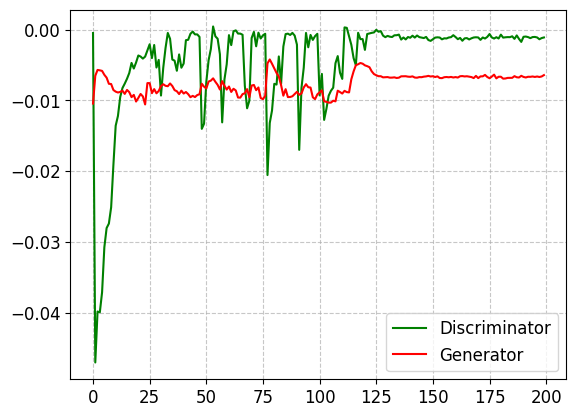

In [85]:
apply_global_style()
plt.plot(range(len(losses_D)), losses_D, color='green', label="Discriminator")
plt.plot(range(len(losses_G)), losses_G, color='red', label="Generator")
plt.legend()
plt.show()

<BarContainer object of 96 artists>

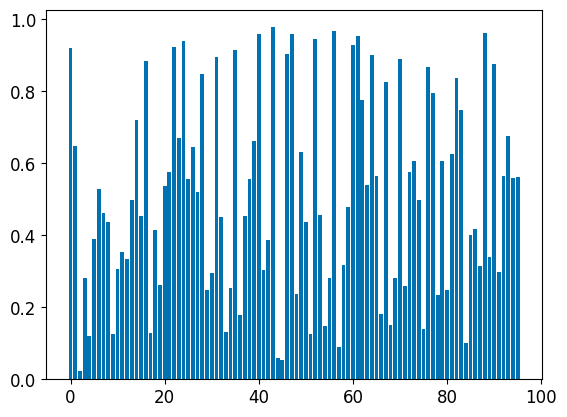

In [86]:
random_hist = torch.rand(96)
plt.bar(range(96), random_hist)

In [87]:
scores = []

dataset = np.asarray(dataset)
mean_hist = dataset.mean(axis=0)

with torch.no_grad():
    for hist in dataset:
        hist = torch.tensor(hist).float()
        hist = hist.unsqueeze(0)
        #score = disc(hist)
        score = torch.norm(critic(hist))
        scores.append(score)       

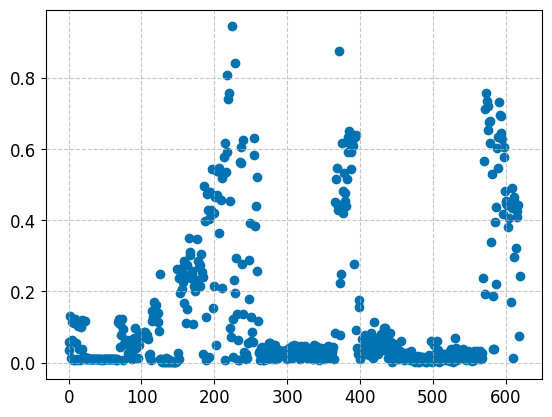

In [88]:
apply_global_style()
plt.scatter(range(len(scores)), scores)
plt.show()

In [89]:
critic(random_hist.unsqueeze(0))

tensor([[0.0070]], grad_fn=<AddmmBackward0>)

In [60]:
outliers = np.where(np.array(scores) > 2.5)
outliers[0]

array([224])

In [ ]:
len([8,  15, 188, 214, 263, 268, 520, 533, 546, 555])

10

In [ ]:
scores.index(min(scores))

244

<BarContainer object of 96 artists>

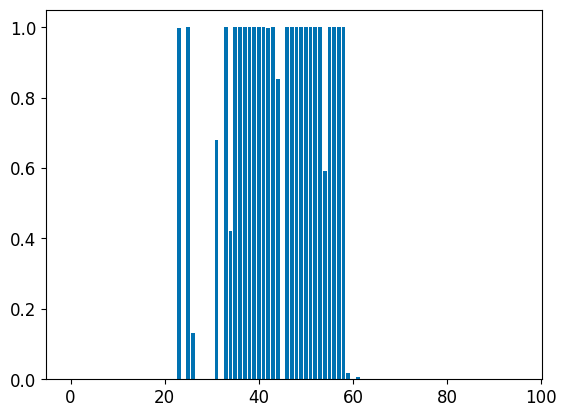

In [ ]:
#rand = torch.randn(1, 1, latent_dim, device=device)
rand = torch.ones(1,1,20)
fake_sample = gen(rand).squeeze().detach().numpy()
plt.bar(range(len(fake_sample)), fake_sample)

<BarContainer object of 96 artists>

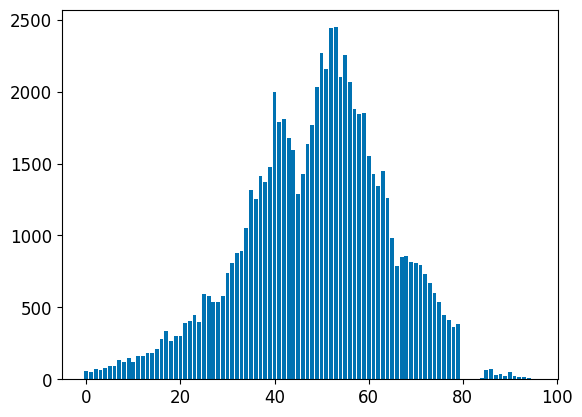

In [61]:
idx = 224
plt.bar(range(len(dataset[idx])), dataset[idx])

In [ ]:
disc(torch.tensor(dataset[610]).unsqueeze(0)).detach().numpy()

array([[1.]], dtype=float32)